# 🚁 YOLO Custom Inference - Fixed Labels

**Hardware:** Mac M4 GPU (`mps`)  
**Fix:** Overriding COCO labels with Drone/Airplane/Helicopter

In [ ]:
!pip install -q ultralytics
import torch
import cv2
import random
import glob
import matplotlib.pyplot as plt
from ultralytics import YOLO

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"✅ Acceleration: {device}")

✅ Acceleration: mps


In [ ]:
# 1. Load your SPECIFIC trained weights (Best of the two you got)
model_path = 'yolo26n.pt' # or 'yolo9s_main.pt'
model = YOLO(model_path)

custom_names = {0: 'Airplane', 1: 'Drone', 2: 'Helicopter'}
model.model.names = custom_names

print(f"✅ Model loaded. Using custom labels: {model.names}")

✅ Model loaded. Using custom labels: {0: 'Airplane', 1: 'Drone', 2: 'Helicopter'}


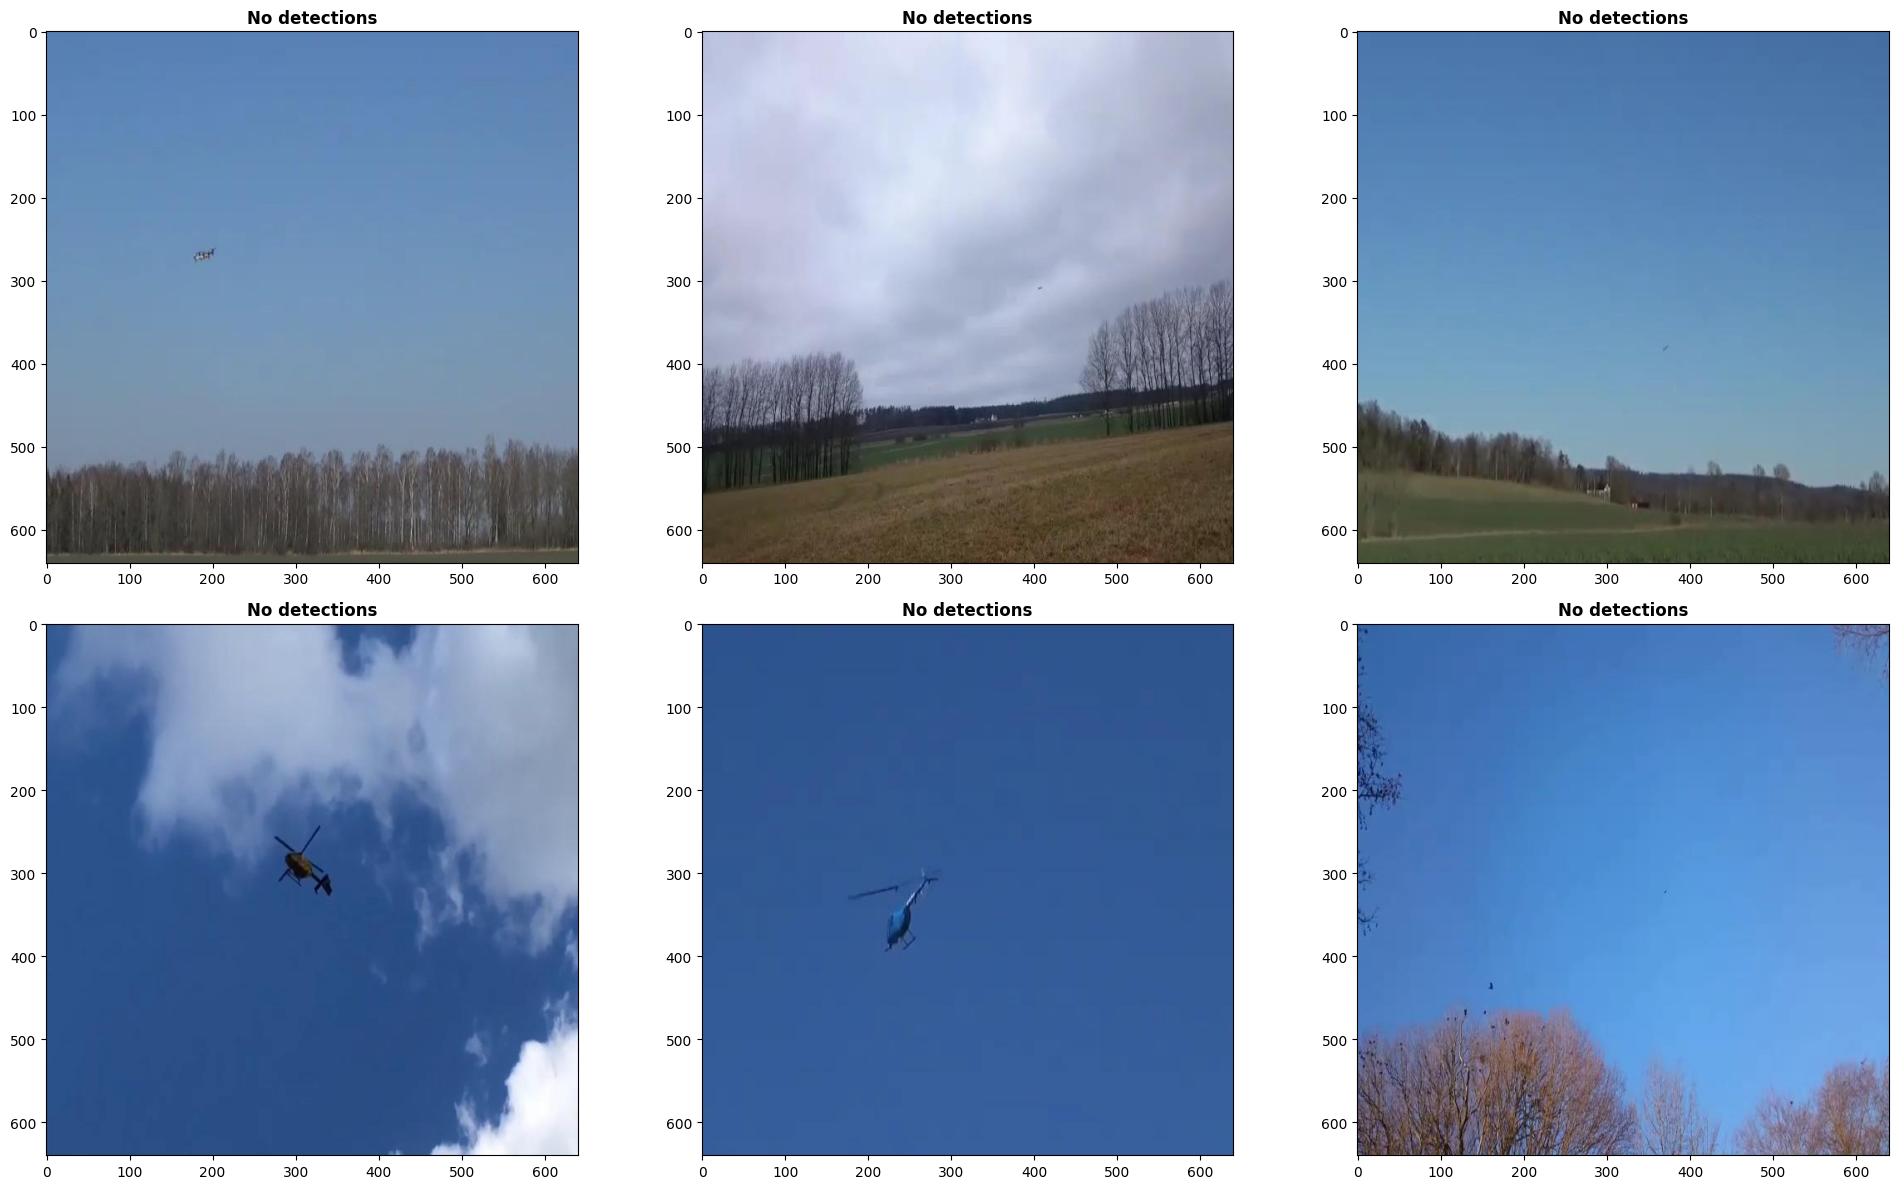

In [ ]:
# 3. Run 6-Image Grid Demo
val_img_path = './drone-dataset/valid/images' # Update to your local path
all_imgs = glob.glob(f"{val_img_path}/*.jpg")
test_imgs = random.sample(all_imgs, min(6, len(all_imgs)))

results = model.predict(test_imgs, conf=0.45, device=device, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# After running predictions
for idx, result in enumerate(results):
    # Filter to only keep class 0 (drone)
    if result.boxes is not None:
        # Keep only detections with class 0
        mask = result.boxes.cls == 0
        result.boxes = result.boxes[mask]
    
    # Now plot
    img_bgr = result.plot()
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    axes[idx].imshow(img_rgb)
    
    detections = {}
    for box in result.boxes:
        cls_id = int(box.cls[0])
        name = custom_names.get(cls_id, f"Unknown:{cls_id}")
        detections[name] = detections.get(name, 0) + 1
    
    title = ', '.join([f'{k}:{v}' for k,v in detections.items()]) if detections else 'No detections'
    axes[idx].set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()